In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1. Data Collection

In [70]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-07,24.582193,25.007976,24.487072,24.901530,127207600
2016-04-08,24.609369,24.860761,24.498393,24.665989,94326800
2016-04-11,24.690903,25.051008,24.647873,24.679580,117630000
2016-04-12,25.012503,25.026091,24.609368,24.763373,108929200
2016-04-13,25.374876,25.442819,25.094041,25.094041,133029200
...,...,...,...,...,...
2026-03-30,246.630005,250.869995,245.509995,250.070007,39446200
2026-03-31,253.789993,255.479996,247.100006,247.910004,49598100


In [71]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-07,24.582193,25.007976,24.487072,24.901530,127207600
2016-04-08,24.609369,24.860761,24.498393,24.665989,94326800
2016-04-11,24.690903,25.051008,24.647873,24.679580,117630000
2016-04-12,25.012503,25.026091,24.609368,24.763373,108929200
2016-04-13,25.374876,25.442819,25.094041,25.094041,133029200


In [72]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-03-30,246.630005,250.869995,245.509995,250.070007,39446200
2026-03-31,253.789993,255.479996,247.100006,247.910004,49598100
2026-04-01,255.630005,256.179993,253.330002,254.080002,40059400
2026-04-02,255.919998,256.130005,250.649994,254.199997,31289400
2026-04-06,258.859985,262.160004,256.459991,256.510010,29297900


# 2. Data Exploration & Visualiztion

In [73]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-07,24.582193,25.007976,24.487072,24.901530,127207600
2016-04-08,24.609369,24.860761,24.498393,24.665989,94326800
2016-04-11,24.690903,25.051008,24.647873,24.679580,117630000
2016-04-12,25.012503,25.026091,24.609368,24.763373,108929200
2016-04-13,25.374876,25.442819,25.094041,25.094041,133029200
...,...,...,...,...,...
2026-03-30,246.630005,250.869995,245.509995,250.070007,39446200
2026-03-31,253.789993,255.479996,247.100006,247.910004,49598100


In [74]:
type(df)

pandas.DataFrame

In [75]:
df.shape

(2513, 5)

In [76]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [77]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,120.265009,121.467337,118.956849,120.162807,9.833511e+07
std,75.247139,75.981741,74.462535,75.196054,5.593056e+07
min,20.584818,20.887868,20.386581,20.507344,1.791060e+07
25%,44.070065,44.390797,43.706592,44.087491,5.914410e+07
50%,126.483261,127.702821,124.524302,125.840235,8.641840e+07
75%,175.908417,177.618361,174.455431,175.755177,1.194232e+08
max,285.922455,288.350192,283.035157,285.932471,4.584084e+08


In [78]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [79]:
df = df.reset_index()

In [80]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-04-07,24.582193,25.007976,24.487072,24.901530,127207600
1,2016-04-08,24.609369,24.860761,24.498393,24.665989,94326800
2,2016-04-11,24.690903,25.051008,24.647873,24.679580,117630000
3,2016-04-12,25.012503,25.026091,24.609368,24.763373,108929200
4,2016-04-13,25.374876,25.442819,25.094041,25.094041,133029200


Text(0, 0.5, 'Close Price')

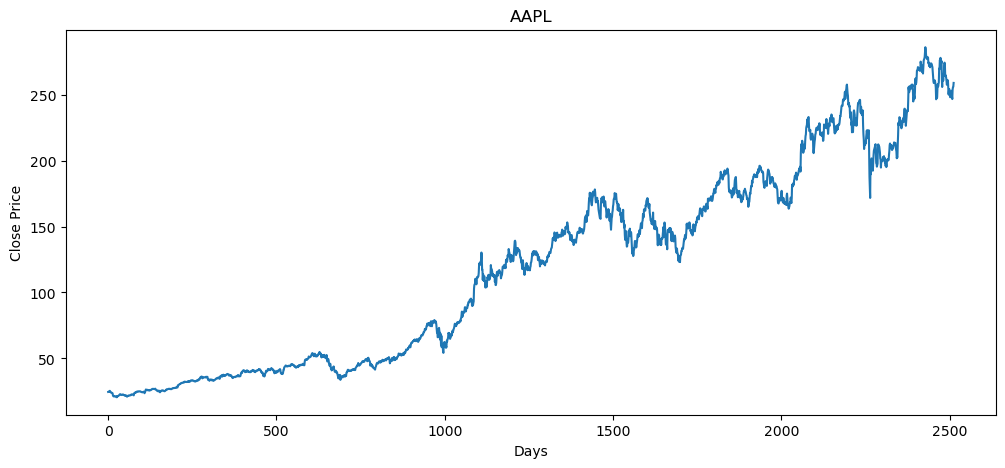

In [81]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close Price')

# 3. Feature Engineering

In [82]:
# 10,20,30,40,50,60,70,80,90,100
# MA of 5 days ==> null null null null 30 40

In [83]:
temp_df = [10,20,30,40,50,60,70,80,90,100]
print(sum(temp_df[:5])/5)

30.0


In [84]:
df1 = pd.DataFrame([10,20,30,40,50,60,70,80,90,100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [85]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


## 100 days Moving Averange

In [86]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head(102)

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-04-07,24.582193,25.007976,24.487072,24.901530,127207600,NaN
1,2016-04-08,24.609369,24.860761,24.498393,24.665989,94326800,NaN
2,2016-04-11,24.690903,25.051008,24.647873,24.679580,117630000,NaN
3,2016-04-12,25.012503,25.026091,24.609368,24.763373,108929200,NaN
4,2016-04-13,25.374876,25.442819,25.094041,25.094041,133029200,NaN
...,...,...,...,...,...,...,...
97,2016-08-24,24.748991,24.913939,24.668809,24.872702,94700400,NaN
98,2016-08-25,24.643612,24.714630,24.439719,24.602375,100344800,NaN
99,2016-08-26,24.499290,24.730674,24.354960,24.606965,111065200,22.890024


Text(0, 0.5, 'Price')

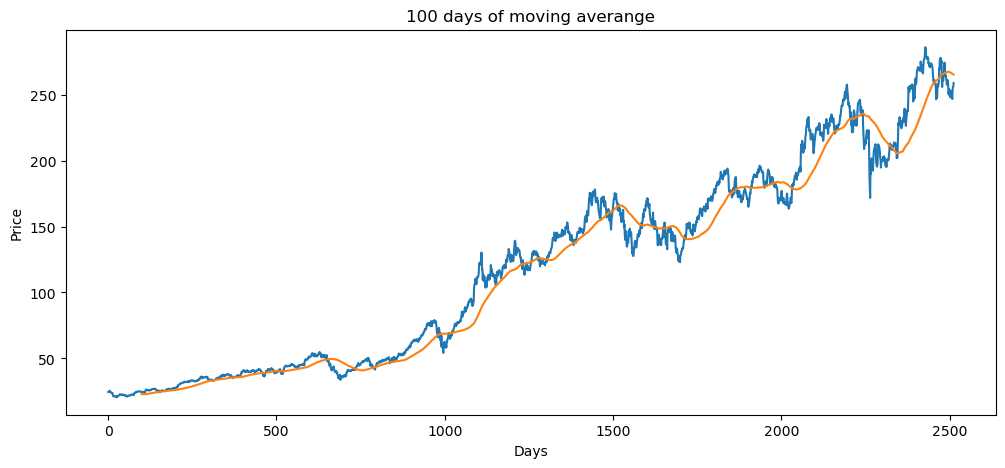

In [87]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'])
plt.title('100 days of moving averange')
plt.xlabel('Days')
plt.ylabel('Price')

## 200 days Moving Averange

In [88]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(202)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-04-07,24.582193,25.007976,24.487072,24.901530,127207600,NaN,NaN
1,2016-04-08,24.609369,24.860761,24.498393,24.665989,94326800,NaN,NaN
2,2016-04-11,24.690903,25.051008,24.647873,24.679580,117630000,NaN,NaN
3,2016-04-12,25.012503,25.026091,24.609368,24.763373,108929200,NaN,NaN
4,2016-04-13,25.374876,25.442819,25.094041,25.094041,133029200,NaN,NaN
...,...,...,...,...,...,...,...,...
197,2017-01-18,27.630093,27.747531,27.565617,27.632396,94852000,25.974964,NaN
198,2017-01-19,27.581738,27.653121,27.487328,27.494236,102389200,26.004345,NaN
199,2017-01-20,27.632395,27.736016,27.570223,27.736016,130391600,26.035676,24.462850


Text(0, 0.5, 'Price')

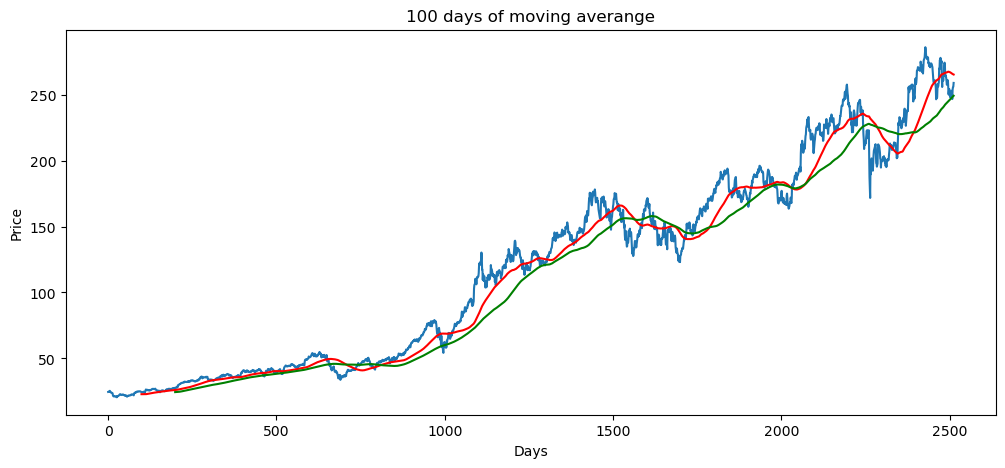

In [89]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'g')
plt.title('100 days of moving averange')
plt.xlabel('Days')
plt.ylabel('Price')

## Calculating % changed in each trading session

In [90]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close','Percentage Changed']]

Price,Close,Percentage Changed
Ticker,AAPL,
0,24.582193,NaN
1,24.609369,0.001106
2,24.690903,0.003313
3,25.012503,0.013025
4,25.374876,0.014488
...,...,...
2508,246.630005,-0.008722
2509,253.789993,0.029031
2510,255.630005,0.007250


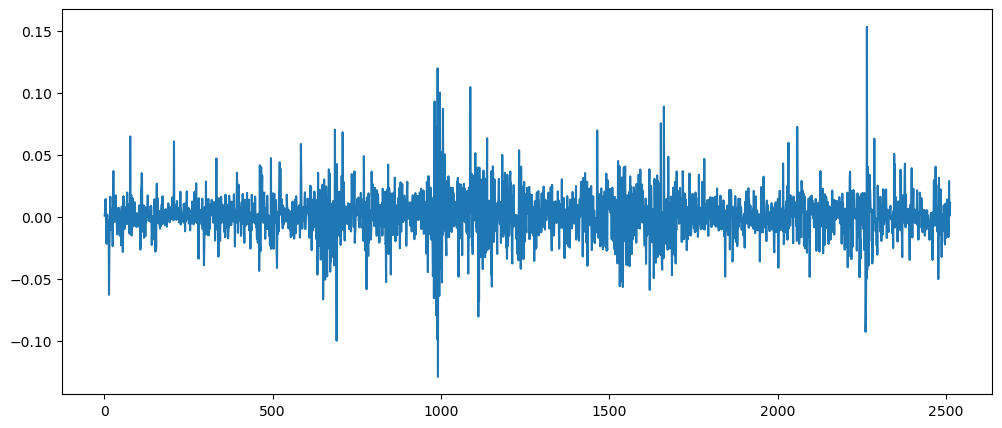

In [91]:
plt.figure(figsize=(12,5))
plt.plot(df['Percentage Changed'])

# 4. Data Preprocessing

In [92]:
# installed librabries for scikit-learn, keras, Tensoreflow
# Spliting data into 2 parts
# 1. 70% of data for data training
# 2. 30% of data for data testing

In [93]:
# Spliting data into Training & Testing datasets
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7):int(len(df))])
print(data_training)
print(data_testing)

Ticker        AAPL
0        24.582193
1        24.609369
2        24.690903
3        25.012503
4        25.374876
...            ...
1754    156.019730
1755    155.398712
1756    158.474152
1757    160.041473
1758    162.545197

[1759 rows x 1 columns]
Ticker        AAPL
1759    163.797043
1760    163.264771
1761    161.421463
1762    162.308640
1763    159.716187
...            ...
2508    246.630005
2509    253.789993
2510    255.630005
2511    255.919998
2512    258.859985

[754 rows x 1 columns]


In [94]:
# Scaling down the data between 0 & 1

In [95]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [96]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.02537712],
       [0.02554965],
       [0.02606726],
       ...,
       [0.87538298],
       [0.88533304],
       [0.90122779]], shape=(1759, 1))

In [97]:
type(data_training_array)

numpy.ndarray

In [98]:
data_training_array.shape

(1759, 1)

# 5. Sequence Creation

In [99]:
x_train = []
y_train = []
for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [100]:
x_train

array([[[0.02537712],
        [0.02554965],
        [0.02606726],
        ...,
        [0.02643603],
        [0.02576703],
        [0.02485082]],

       [[0.02554965],
        [0.02606726],
        [0.02810892],
        ...,
        [0.02576703],
        [0.02485082],
        [0.02467625]],

       [[0.02606726],
        [0.02810892],
        [0.03040943],
        ...,
        [0.02485082],
        [0.02467625],
        [0.02348365]],

       ...,

       [[0.7740011 ],
        [0.73563812],
        [0.73395094],
        ...,
        [0.87212913],
        [0.85980121],
        [0.85585872]],

       [[0.73563812],
        [0.73395094],
        [0.7373252 ],
        ...,
        [0.85980121],
        [0.85585872],
        [0.87538298]],

       [[0.73395094],
        [0.7373252 ],
        [0.740949  ],
        ...,
        [0.85585872],
        [0.87538298],
        [0.88533304]]], shape=(1659, 100, 1))

In [101]:
y_train

array([0.02467625, 0.02348365, 0.02362909, ..., 0.87538298, 0.88533304,
       0.90122779], shape=(1659,))

In [102]:
x_train.ndim

3

In [103]:
y_train.ndim

1

In [104]:
x_train.shape

(1659, 100, 1)

In [105]:
y_train.shape

(1659,)

# 6. Model Building

In [106]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [107]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input


In [108]:
model = Sequential()

model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

# 7. Model Training

In [109]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0153
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 7.8033e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 6.8430e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 6.3318e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 6.2200e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 5.8146e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 6.0218e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 5.6745e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 5.1452e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 4.9942e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 5.2498e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 4.5352e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 4.3904e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 4.9260e-04
Epoch 15/50
52/52 

In [110]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [111]:
# Save The Trained Model
model.save('stock_prediction_model.keras')

# 8. Preparing Test Data

In [112]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200,Percentage Changed
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,,
0,2016-04-07,24.582193,25.007976,24.487072,24.901530,127207600,NaN,NaN,NaN
1,2016-04-08,24.609369,24.860761,24.498393,24.665989,94326800,NaN,NaN,0.001106
2,2016-04-11,24.690903,25.051008,24.647873,24.679580,117630000,NaN,NaN,0.003313
3,2016-04-12,25.012503,25.026091,24.609368,24.763373,108929200,NaN,NaN,0.013025
4,2016-04-13,25.374876,25.442819,25.094041,25.094041,133029200,NaN,NaN,0.014488
...,...,...,...,...,...,...,...,...,...
2508,2026-03-30,246.630005,250.869995,245.509995,250.070007,39446200,265.752922,247.938607,-0.008722
2509,2026-03-31,253.789993,255.479996,247.100006,247.910004,49598100,265.595559,248.214578,0.029031
2510,2026-04-01,255.630005,256.179993,253.330002,254.080002,40059400,265.455598,248.513458,0.007250


In [113]:
data_training

Ticker,AAPL
0,24.582193
1,24.609369
2,24.690903
3,25.012503
4,25.374876
...,...
1754,156.019730
1755,155.398712
1756,158.474152
1757,160.041473


In [114]:
data_testing

Ticker,AAPL
1759,163.797043
1760,163.264771
1761,161.421463
1762,162.308640
1763,159.716187
...,...
2508,246.630005
2509,253.789993
2510,255.630005
2511,255.919998


In [115]:
past_100_days = data_training.tail(100)
past_100_days

Ticker,AAPL
1659,136.727448
1660,137.298264
1661,132.741379
1662,144.551941
1663,147.337265
...,...
1754,156.019730
1755,155.398712
1756,158.474152
1757,160.041473


In [116]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True) 
final_df

Ticker,AAPL
0,136.727448
1,137.298264
2,132.741379
3,144.551941
4,147.337265
...,...
849,246.630005
850,253.789993
851,255.630005
852,255.919998


In [117]:
input_data = scaler.fit_transform(final_df)
input_data

array([[8.39944356e-02],
       [8.74990479e-02],
       [5.95213570e-02],
       [1.32034109e-01],
       [1.49135033e-01],
       [1.40554452e-01],
       [1.51189890e-01],
       [1.43636270e-01],
       [1.55298856e-01],
       [1.58743042e-01],
       [1.38922857e-01],
       [1.52035760e-01],
       [1.57413765e-01],
       [1.39527023e-01],
       [1.16021228e-01],
       [9.75904654e-02],
       [1.39043803e-01],
       [1.40735636e-01],
       [1.37714338e-01],
       [1.30583980e-01],
       [1.08105052e-01],
       [9.62005745e-02],
       [1.06533696e-01],
       [1.03572917e-01],
       [1.17652355e-01],
       [1.23574380e-01],
       [1.09917644e-01],
       [6.93707896e-02],
       [5.73457412e-02],
       [4.44141159e-02],
       [4.39912278e-02],
       [6.30258757e-02],
       [4.35683398e-02],
       [4.13324853e-02],
       [3.02741587e-02],
       [6.16368279e-03],
       [2.77364086e-02],
       [2.96698054e-02],
       [3.02129833e-04],
       [8.09736057e-03],


In [118]:
input_data.shape

(854, 1)

In [119]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

x_test, y_test = np.array(x_test), np.array(y_test)

In [120]:
x_test

array([[[0.08399444],
        [0.08749905],
        [0.05952136],
        ...,
        [0.21751165],
        [0.22713446],
        [0.24250645]],

       [[0.08749905],
        [0.05952136],
        [0.13203411],
        ...,
        [0.22713446],
        [0.24250645],
        [0.25019236]],

       [[0.05952136],
        [0.13203411],
        [0.14913503],
        ...,
        [0.24250645],
        [0.25019236],
        [0.24692439]],

       ...,

       [[0.89994603],
        [0.89767851],
        [0.88971221],
        ...,
        [0.77208103],
        [0.75875799],
        [0.80271784]],

       [[0.89767851],
        [0.88971221],
        [0.89719566],
        ...,
        [0.75875799],
        [0.80271784],
        [0.81401487]],

       [[0.88971221],
        [0.89719566],
        [0.93289495],
        ...,
        [0.80271784],
        [0.81401487],
        [0.81579533]]], shape=(754, 100, 1))

In [121]:
y_test

array([0.25019236, 0.24692439, 0.23560712, 0.24105408, 0.22513731,
       0.2176933 , 0.21345702, 0.24650075, 0.24438266, 0.24450351,
       0.25200804, 0.25902832, 0.25309721, 0.2432325 , 0.24510871,
       0.23566773, 0.23560712, 0.26374895, 0.27143485, 0.27089008,
       0.26453542, 0.25793906, 0.24789252, 0.29497737, 0.29455354,
       0.28408355, 0.29491666, 0.29606653, 0.29036972, 0.28733952,
       0.28733952, 0.29109689, 0.3053993 , 0.30606605, 0.30024801,
       0.28424871, 0.28594551, 0.29291511, 0.30770232, 0.31903524,
       0.31873208, 0.33594355, 0.34115545, 0.33285255, 0.33061042,
       0.32218638, 0.33885243, 0.34121588, 0.35836673, 0.35545776,
       0.35933655, 0.37182074, 0.36521501, 0.36576025, 0.35939716,
       0.37782043, 0.37588108, 0.36733629, 0.38424432, 0.39145627,
       0.39351666, 0.42006108, 0.41090988, 0.40406188, 0.40697085,
       0.40012229, 0.38757768, 0.38436573, 0.39460761, 0.39927408,
       0.40018319, 0.4201824 , 0.41860655, 0.42690936, 0.41497

In [122]:
x_test[0].shape

(100, 1)

# 9. Making Predictions

In [123]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step


In [124]:
y_predicted

array([[0.22811718],
       [0.23994868],
       [0.24378917],
       [0.23817924],
       [0.23608015],
       [0.22743978],
       [0.21833181],
       [0.21171682],
       [0.22539797],
       [0.23556828],
       [0.24053484],
       [0.24584097],
       [0.25191212],
       [0.25175473],
       [0.24526416],
       [0.24170594],
       [0.23557574],
       [0.23219061],
       [0.24546611],
       [0.2593994 ],
       [0.2663657 ],
       [0.2650466 ],
       [0.2591726 ],
       [0.2500312 ],
       [0.26950476],
       [0.2839534 ],
       [0.28460097],
       [0.28819725],
       [0.2906354 ],
       [0.28829896],
       [0.2846827 ],
       [0.28276426],
       [0.28428417],
       [0.2935421 ],
       [0.2996976 ],
       [0.29892585],
       [0.2885838 ],
       [0.28309533],
       [0.28505382],
       [0.2954499 ],
       [0.3081845 ],
       [0.31434584],
       [0.3255712 ],
       [0.33400953],
       [0.33218515],
       [0.32813767],
       [0.32093132],
       [0.326

In [137]:
y_test

array([26801.59762417, 26714.90341774, 26414.67350003, 26559.17295679,
       26136.92547296, 25939.44718988, 25827.06507479, 26703.6649577 ,
       26647.4751428 , 26650.68116081, 26849.76493819, 27036.00227595,
       26878.65886486, 26616.96329542, 26666.73610372, 26416.28147961,
       26414.67350003, 27161.23331594, 27365.12860562, 27350.67667171,
       27182.09728587, 27007.105864  , 26740.58635583, 27989.67582598,
       27978.43239537, 27700.67939774, 27988.06536112, 28018.56975265,
       27867.44204004, 27787.05548765, 27787.05548765, 27886.73282439,
       28266.15387227, 28283.84164761, 28129.49797585, 27705.06095568,
       27750.07444268, 27934.96724111, 28327.24964032, 28627.89460067,
       28619.8522175 , 29076.44634391, 29214.71021991, 28994.44684137,
       28934.96650876, 28711.48965636, 29153.61445186, 29216.31322891,
       29671.29937574, 29594.1287825 , 29697.02704896, 30028.21368013,
       29852.97372973, 29867.43809006, 29698.63502854, 30187.37632005,
      

In [138]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [136]:
y_predicted

array([26215.977, 26529.85 , 26631.73 , 26482.906, 26427.22 , 26198.006,
       25956.385, 25780.9  , 26143.84 , 26413.643, 26545.396, 26686.16 ,
       26847.219, 26843.045, 26670.861, 26576.465, 26413.84 , 26324.037,
       26676.217, 27045.85 , 27230.652, 27195.658, 27039.83 , 26797.32 ,
       27313.924, 27697.225, 27714.406, 27809.809, 27874.49 , 27812.51 ,
       27716.572, 27665.68 , 27706.   , 27951.598, 28114.895, 28094.42 ,
       27820.064, 27674.46 , 27726.416, 28002.21 , 28340.041, 28503.494,
       28801.283, 29025.14 , 28976.742, 28869.367, 28678.197, 28833.035,
       28994.193, 29337.3  , 29471.672, 29556.82 , 29774.268, 29775.268,
       29749.047, 29629.584, 29856.83 , 29972.408, 29873.25 , 30071.076,
       30308.377, 30445.045, 30915.438, 30991.816, 30848.693, 30801.518,
       30678.346, 30418.57 , 30253.322, 30374.734, 30548.182, 30648.15 ,
       31007.785, 31153.275, 31312.465, 31164.367, 30940.098, 30920.734,
       31029.264, 31183.947, 31125.457, 31342.082, 

In [128]:
y_test

array([163.79704285, 163.26477051, 161.42146301, 162.30863953,
       159.71618652, 158.5037384 , 157.81375122, 163.19577026,
       162.8507843 , 162.87046814, 164.09277344, 165.23620605,
       164.27017212, 162.66345215, 162.96903992, 161.43133545,
       161.42146301, 166.00508118, 167.25692749, 167.16819763,
       166.13317871, 165.05879211, 163.42245483, 171.09143066,
       171.0223999 , 169.3170929 , 171.08154297, 171.26882935,
       170.34095764, 169.84741211, 169.84741211, 170.45939636,
       172.78890991, 172.89750671, 171.94989014, 169.34399414,
       169.62036133, 170.75553894, 173.16401672, 175.00987244,
       174.960495  , 177.76382446, 178.61271667, 177.26037598,
       176.89518738, 175.52311707, 178.23760986, 178.62255859,
       181.41601562, 180.94221497, 181.57397461, 183.60734558,
       182.53143311, 182.62023926, 181.58384705, 184.58454895,
       184.26867676, 182.87693787, 185.63084412, 186.80549622,
       187.14108276, 191.46452332, 189.97401428, 188.85

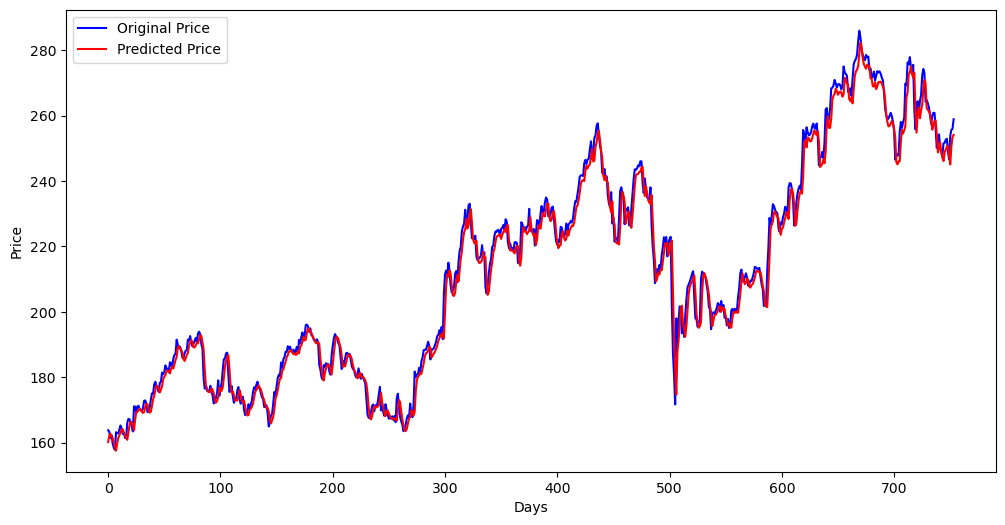

In [129]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(180.0, 280.0)

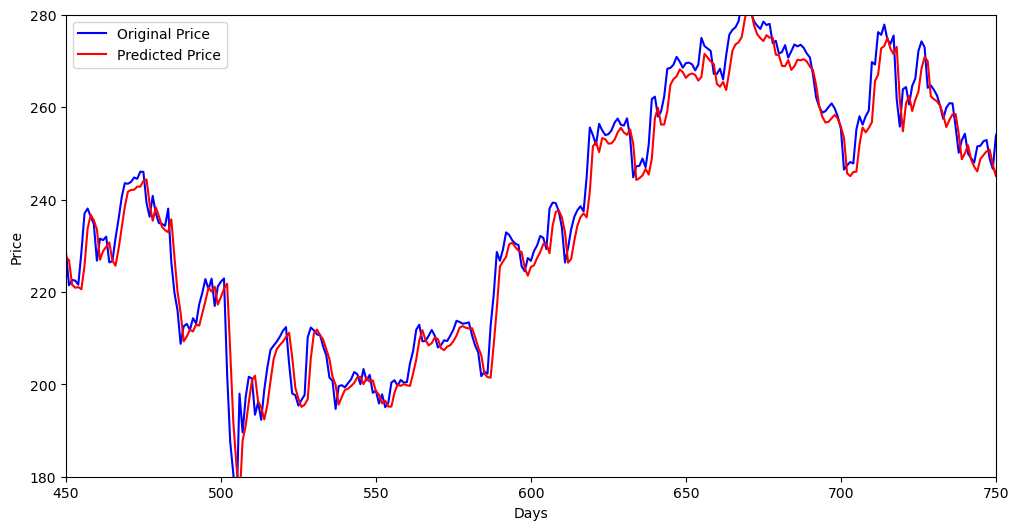

In [130]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450, 750)
plt.ylim(180, 280)

# 10. Model Evaluation

In [131]:
# Mean Squared Error (MSE)
from sklearn.metrics import mean_squared_error, r2_score

In [132]:
mse = mean_squared_error(y_test, y_predicted)
print(f'Mean Squared Error (MSE): {mse}')

Mean Squared Error (MSE): 14.922102727005516


In [133]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (MSE): {rmse}')

Root Mean Squared Error (MSE): 3.8629137612695312


In [134]:
# R-Squared
r2 = r2_score(y_test, y_predicted)
print(f'R-Squared: {r2}')

R-Squared: 0.9863667626500982
